In [52]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/imakash3011/customer-personality-analysis/marketing_campaign.csv


In [53]:
# Load Libraries

# Data handling
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, SpectralClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA


In [54]:
# Load Data

# Load dataset
data = pd.read_csv('/kaggle/input/datasets/imakash3011/customer-personality-analysis/marketing_campaign.csv', sep='\t')

# Display shapes
print("Data Shape:", data.shape)

# Preview
data.head()

Data Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0



--- Missing Values ---
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


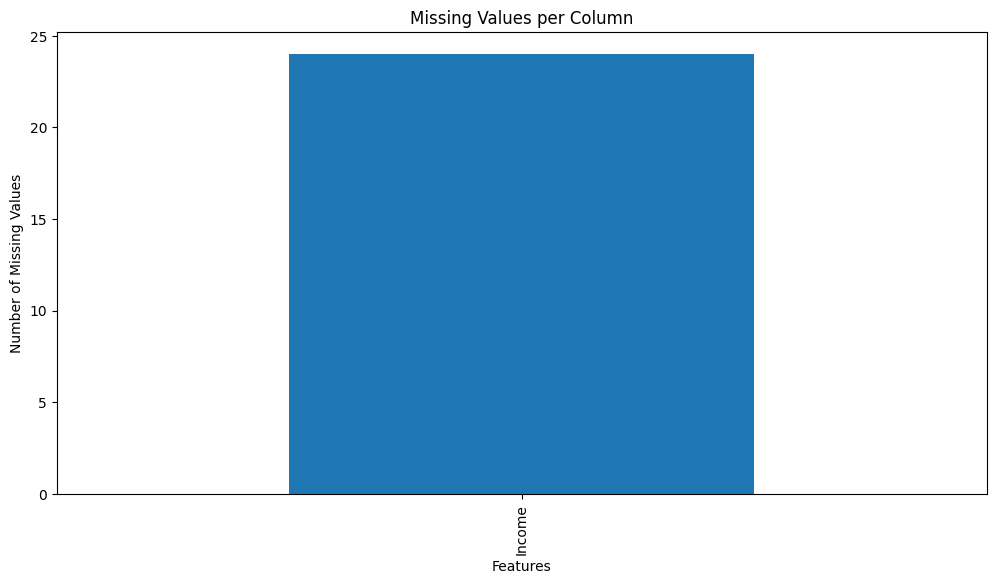


--- Duplicate Rows ---
0
Remaining missing values: 0
Duplicates removed.
Data types fixed.
Before removing outliers:


/tmp/ipykernel_55/3888347958.py:45: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


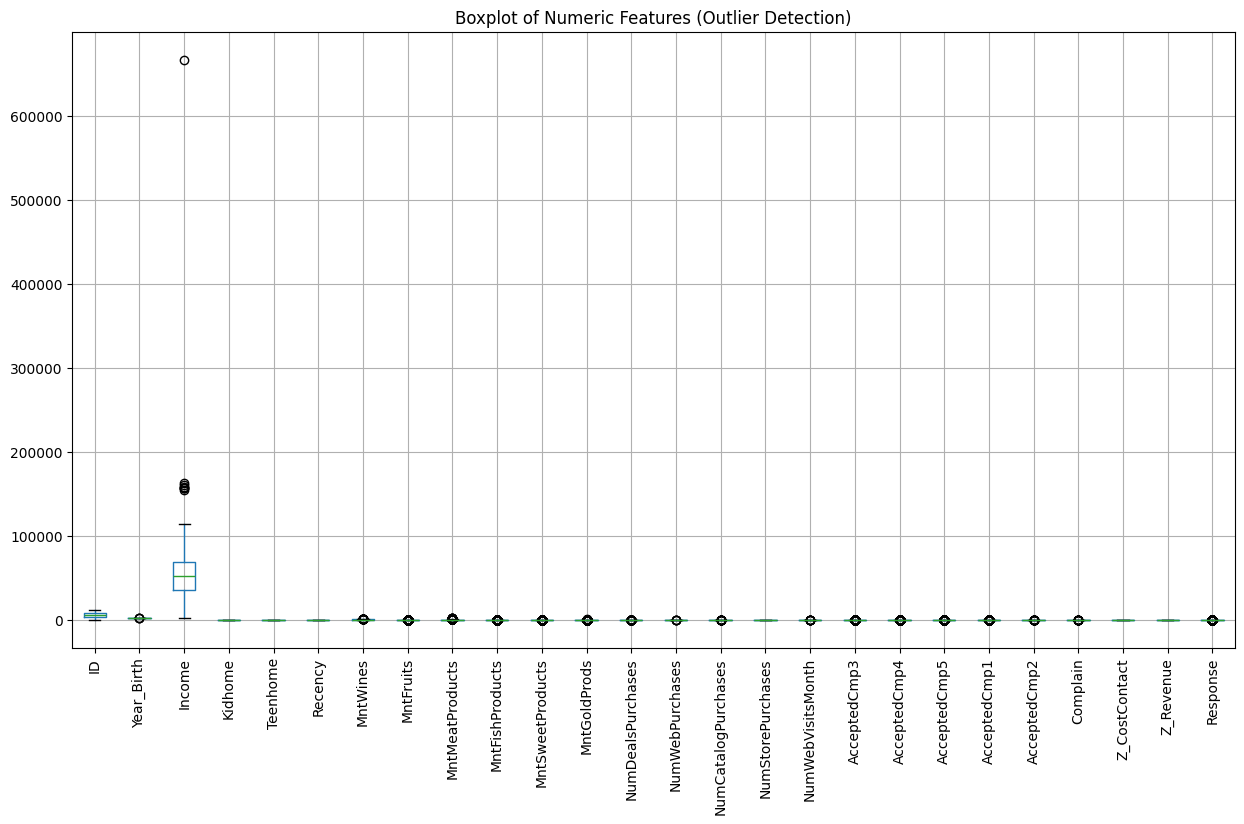

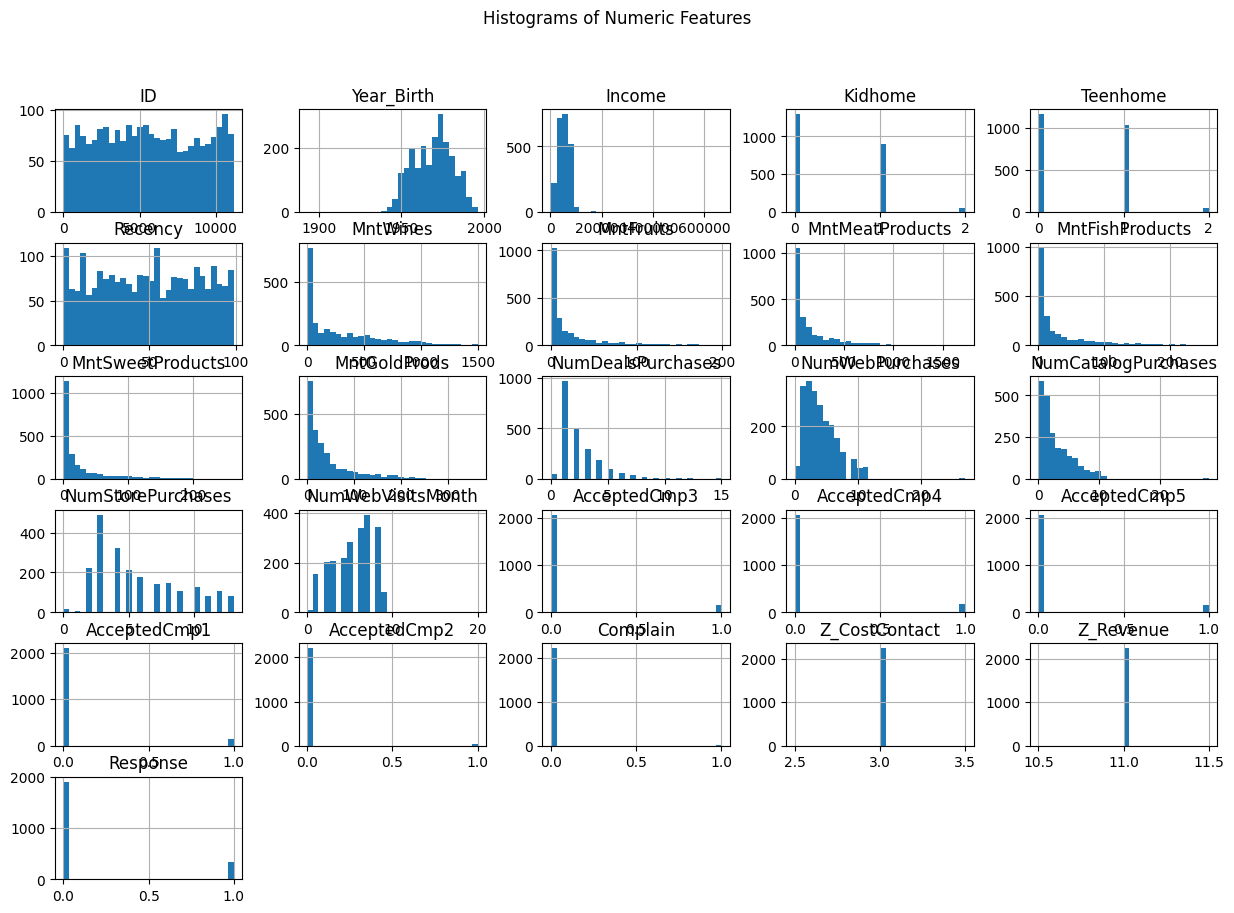

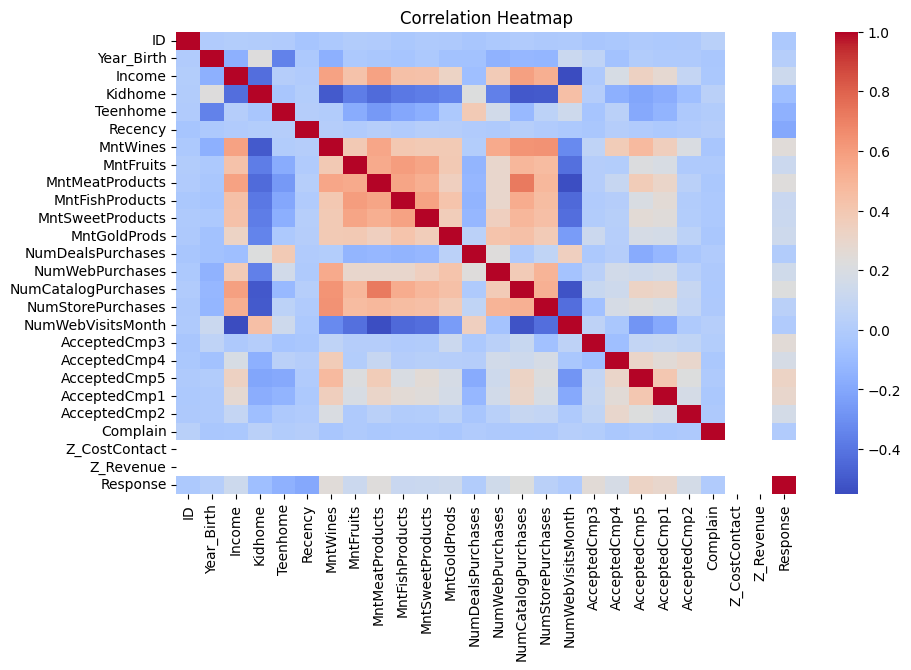

Outliers removed. Remaining rows: 1208
After removing outliers:


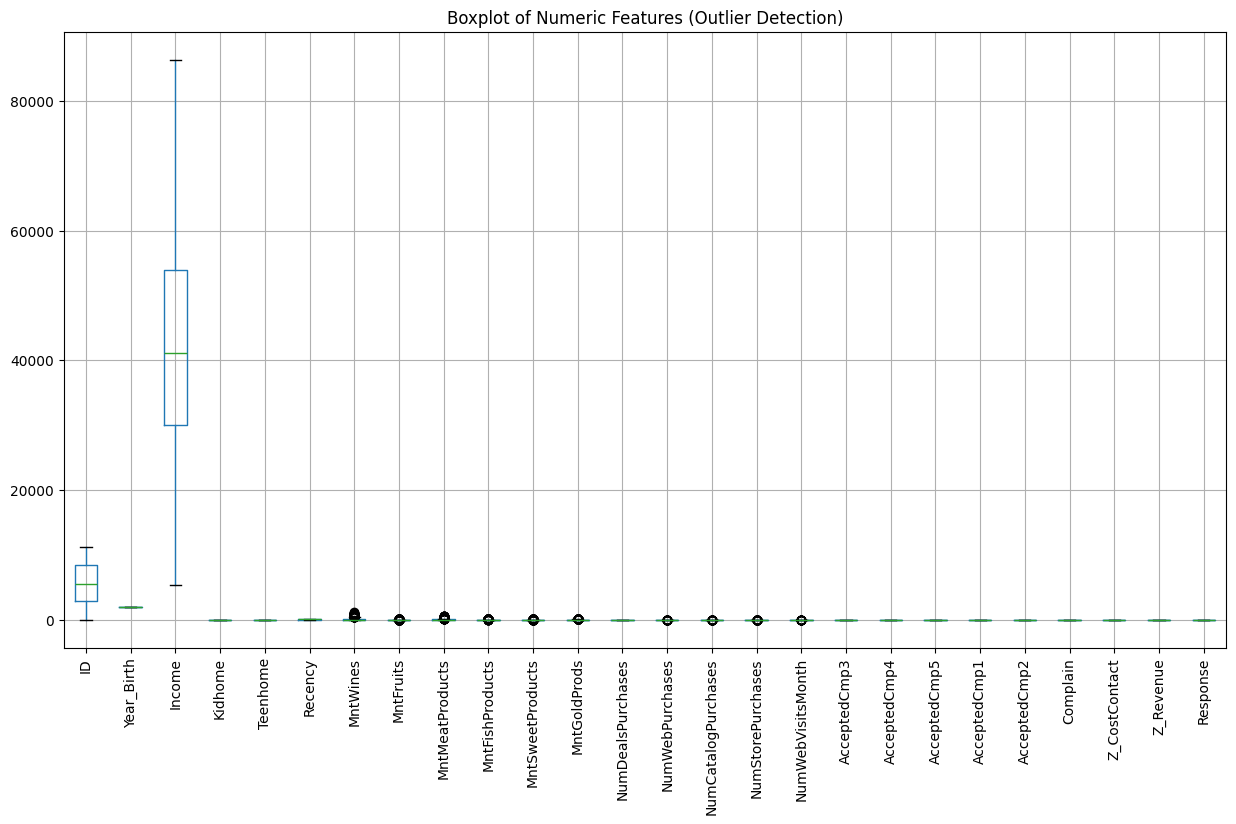

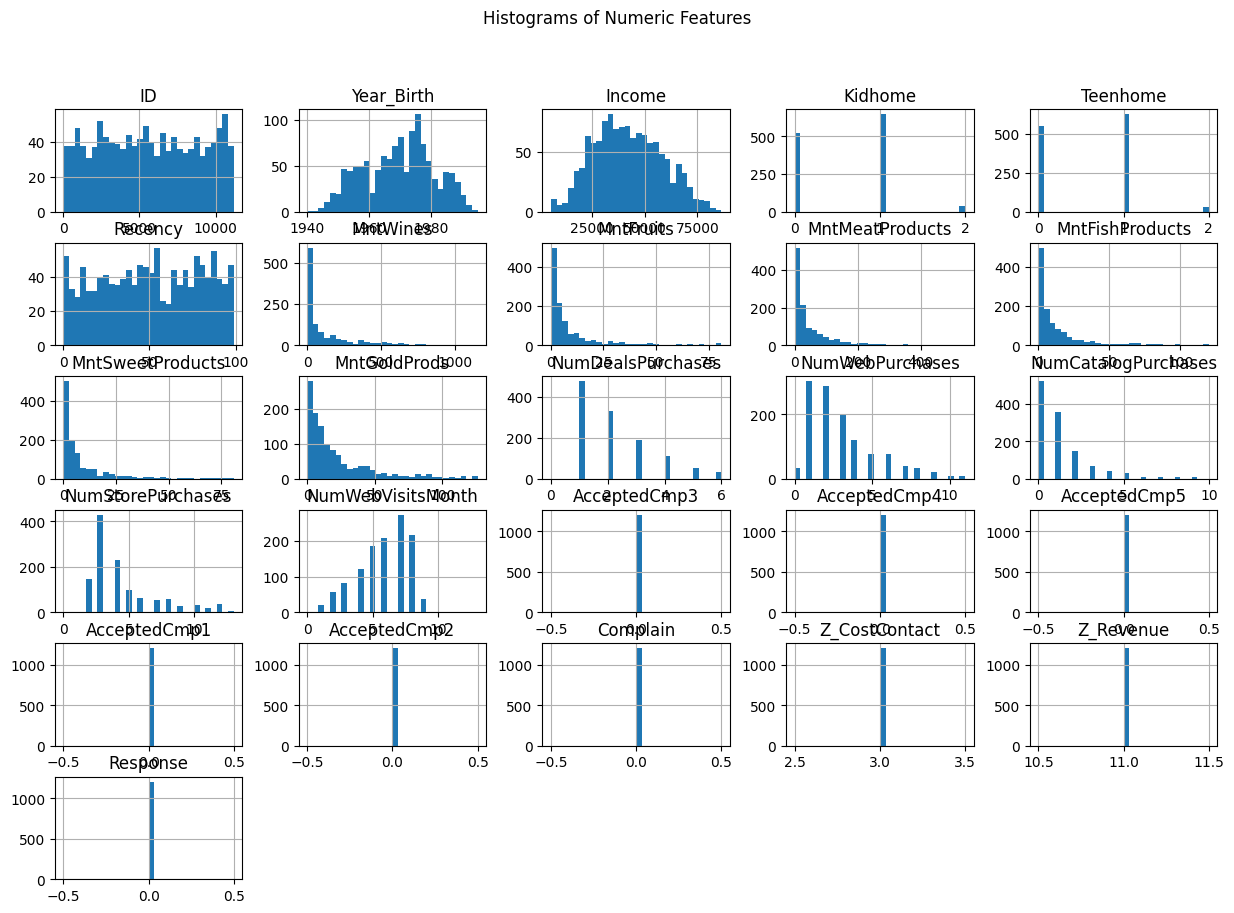

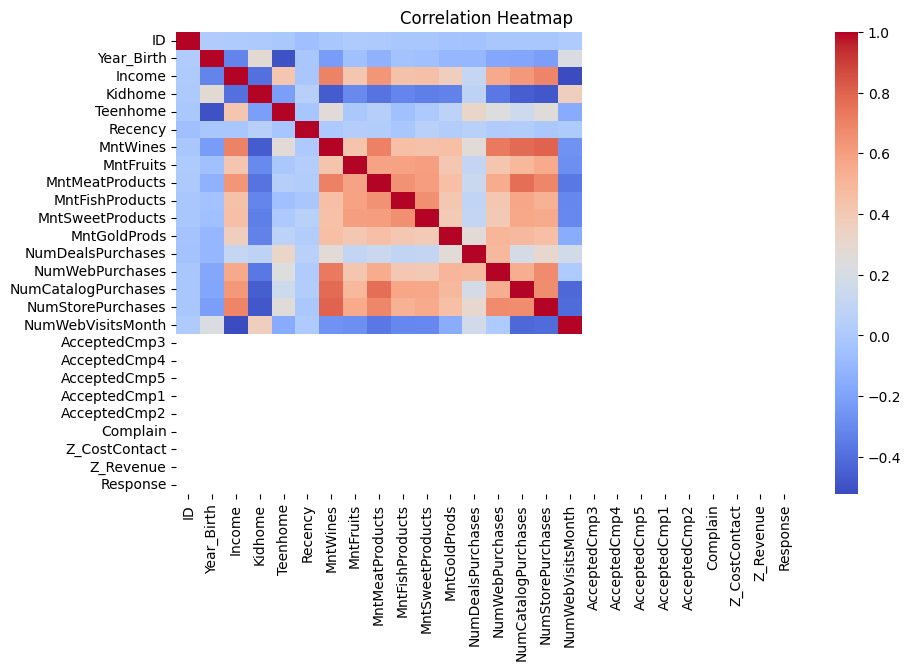

Data normalized safely.
Cleaned data saved to /kaggle/working/cleaned_data_train.csv


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
1,0.193615,0.254545,Graduation,Single,0.506323,0.5,0.5,08-03-2014,0.383838,0.009574,...,0.384615,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.369522,0.454545,Graduation,Together,0.818082,0.0,0.0,21-08-2013,0.262626,0.370757,...,0.307692,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.552048,0.800000,Graduation,Together,0.263297,0.5,0.0,10-02-2014,0.262626,0.009574,...,0.461538,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.475317,0.745455,PhD,Married,0.653745,0.5,0.0,19-01-2014,0.949495,0.150566,...,0.384615,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.665087,0.490909,Master,Together,0.705810,0.0,0.5,09-09-2013,0.161616,0.452567,...,0.461538,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
# Cleaning process

def data_overview(df):
    # Count missing values
    missing = df.isnull().sum()
    print("\n--- Missing Values ---")
    print(missing)

    if(missing.sum() > 0):
        # Filter columns with missing values
        missing = missing[missing > 0].sort_values(ascending=False)

        # Plot bar chart
        plt.figure(figsize=(12,6))
        missing.plot(kind='bar')

        plt.title('Missing Values per Column')
        plt.xlabel('Features')
        plt.ylabel('Number of Missing Values')

        plt.show()
        
    print("\n--- Duplicate Rows ---")
    print(df.duplicated().sum().sum())

    return df

# =========================
# Handle Missing Values
# =========================
def handle_missing_values(df):

    # 1. Replace common fake missing values with actual NaN
    df = df.replace(
    ["NA", "N/A", "null", "?", "", "None", "nan", "NaN", " "],
    np.nan)
    

    # 2. Drop columns with more than 50% missing values
    threshold = len(df) * 0.5
    df = df.dropna(thresh=threshold, axis=1)

    # 3. Attempt to convert columns to numeric where possible
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')

    # Identify numeric and categorical columns
    num_cols = df.select_dtypes(include=np.number).columns
    cat_cols = df.select_dtypes(include='object').columns

    # 4. Fill missing values in numeric columns with mean
    df.loc[:, num_cols] = df[num_cols].fillna(df[num_cols].mean())

    # 5. Fill missing values in categorical columns
    for col in cat_cols:
        if df[col].mode().empty:
            # If no mode exists (all values are NaN), fill with placeholder
            df.loc[:, col] = df[col].fillna("Unknown")
        else:
            # Fill with most frequent value
            df.loc[:, col] = df[col].fillna(df[col].mode()[0])
    
    # 7. Final check: drop any remaining missing values
    df = df.dropna()

    # Print remaining missing values (should be zero)
    print("Remaining missing values:", df.isnull().sum().sum())

    return df

# =========================
# Remove Duplicates
# =========================
def remove_duplicates(df):
    df = df.drop_duplicates()
    print("Duplicates removed.")
    return df


# =========================
# Fix Data Types
# =========================
def fix_data_types(df):
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass

    print("Data types fixed.")
    return df


# =========================
# Handle Outliers (IQR)
# =========================
def remove_outliers(df):
    num_cols = df.select_dtypes(include=np.number).columns

    mask = pd.Series(True, index=df.index)

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        mask &= df[col].between(lower_bound, upper_bound)

    df_cleaned = df[mask]

    print(f"Outliers removed. Remaining rows: {len(df_cleaned)}")
    return df_cleaned


def visualize_outliers(df):
    num_cols = df.select_dtypes(include=np.number).columns

    # 1. Boxplot
    plt.figure(figsize=(15, 8))
    df[num_cols].boxplot(rot=90)
    plt.title("Boxplot of Numeric Features (Outlier Detection)")
    plt.show()

    # 2. Histogram
    df[num_cols].hist(figsize=(15, 10), bins=30)
    plt.suptitle("Histograms of Numeric Features")
    plt.show()

    # 3. Heatmap correlation
    plt.figure(figsize=(10, 6))
    sns.heatmap(df[num_cols].corr(), cmap="coolwarm", annot=False)
    plt.title("Correlation Heatmap")
    plt.show()
    
# =========================
# Normalize Data
# =========================
def normalize_data(df):
    num_cols = df.select_dtypes(include=np.number).columns

    min_vals = df[num_cols].min()
    max_vals = df[num_cols].max()

    denom = (max_vals - min_vals).replace(0, 1)

    df[num_cols] = (df[num_cols] - min_vals) / denom

    print("Data normalized safely.")
    return df

# =========================
# Full Pipeline
# =========================
def clean_data_pipeline(df, save_path=None):
    df = data_overview(df)
    df = handle_missing_values(df)
    df = remove_duplicates(df)
    df = fix_data_types(df)
    print('Before removing outliers:')
    visualize_outliers(df)
    df = remove_outliers(df)
    print('After removing outliers:')
    visualize_outliers(df)
    df = normalize_data(df)

    if save_path:
        df.to_csv(save_path, index=False)
        print(f"Cleaned data saved to {save_path}")

    return df


cleaned_df = clean_data_pipeline(data, '/kaggle/working/cleaned_data_train.csv')

# Preview
cleaned_df.head()

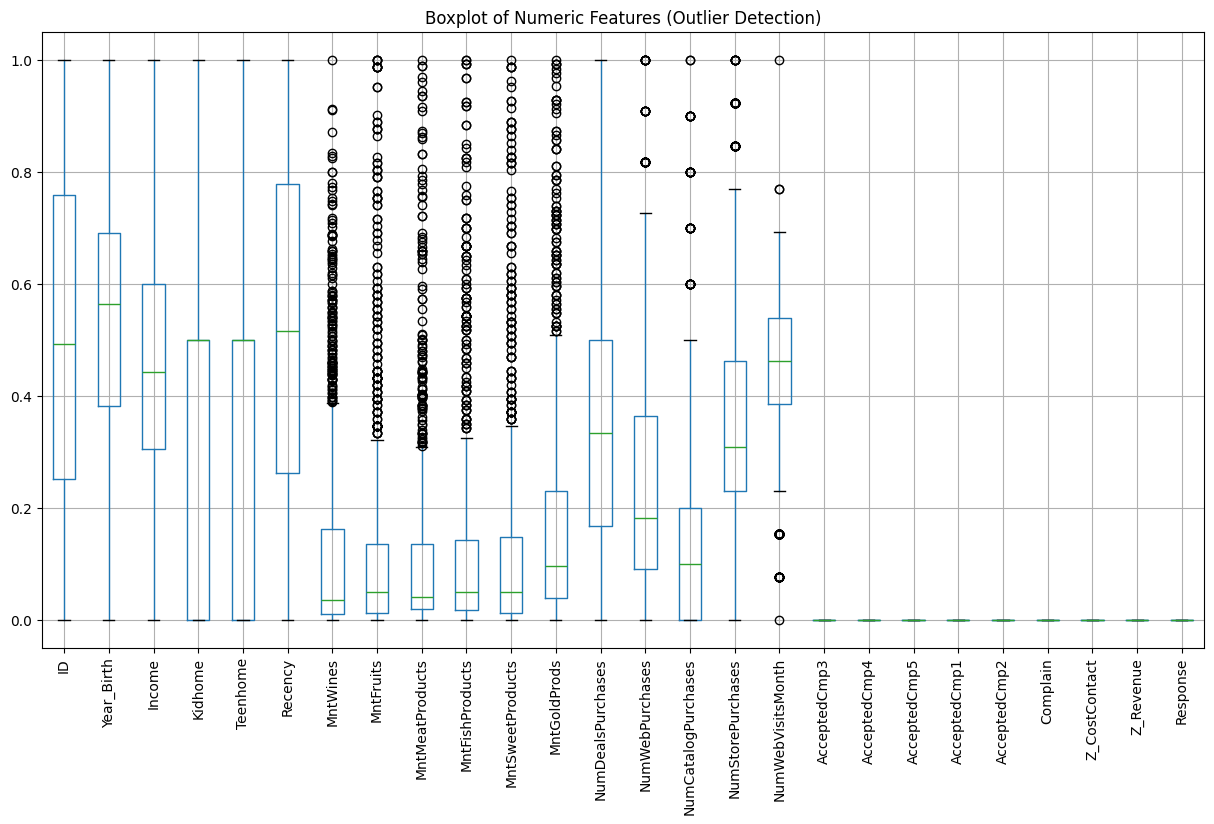

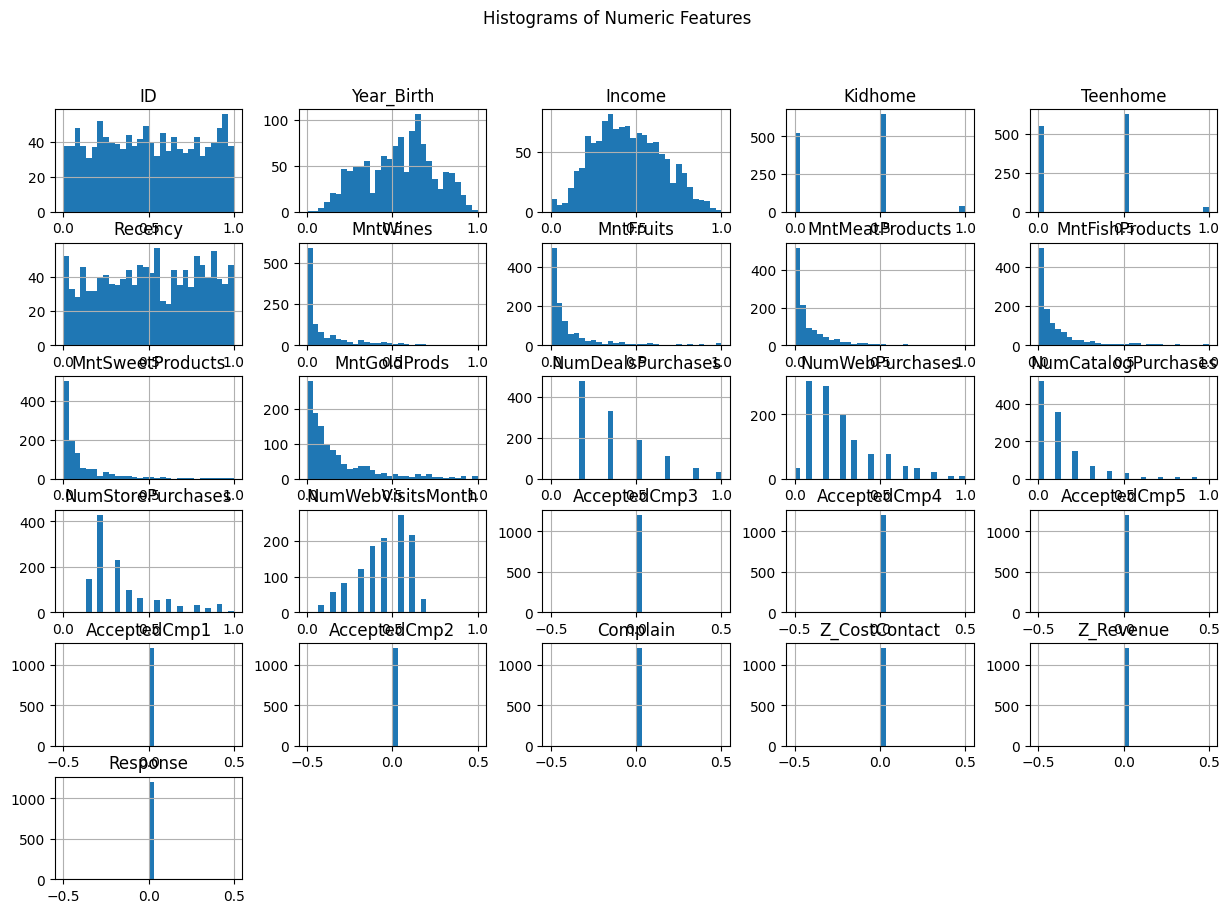

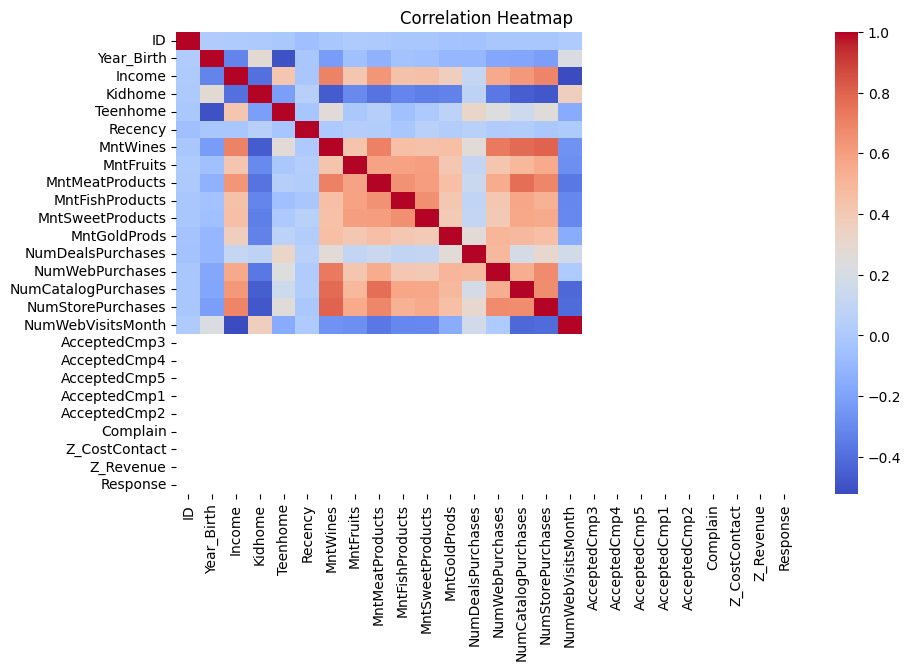

In [56]:
visualize_outliers(cleaned_df)

In [57]:
cleaned_df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [58]:
# =========================
# Copy Data
# =========================
df = cleaned_df.copy()

# =========================
# Fix Types
# =========================
product_cols = [
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

df[product_cols] = df[product_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# =========================
# Behavioral Features
# =========================

# Frequency (total purchases)
df['Frequency'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

# Monetary (total spending)
df['Monetary'] = df[product_cols].sum(axis=1)

# Deal sensitivity
df['Deal_Purchase_Ratio'] = df['NumDealsPurchases'] / (df['Frequency'] + 1)

# Web behavior
df['Web_Engagement'] = df['NumWebPurchases'] / (df['NumWebVisitsMonth'] + 1)

# Campaign response
df['Campaign_Acceptance'] = (
    df['AcceptedCmp1'] + df['AcceptedCmp2'] + df['AcceptedCmp3'] +
    df['AcceptedCmp4'] + df['AcceptedCmp5'] + df['Response']
)

df['Campaign_Engagement_Rate'] = df['Campaign_Acceptance'] / 6

# Product diversity (count-based)
df['Product_Diversity'] = (df[product_cols] > 0).sum(axis=1)


# =========================
# Demographic Features
# =========================

# Age
current_year = pd.Timestamp.now().year
df['Age'] = current_year - df['Year_Birth']

# Customer tenure
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce', dayfirst=True)
df['Customer_Tenure'] = (
    df['Dt_Customer'].max() - df['Dt_Customer']
).dt.days

# Household size
df['Household_Size'] = df['Kidhome'] + df['Teenhome'] + 1


# =========================
# Spending Behavior Ratios
# =========================

df['Wine_Ratio'] = df['MntWines'] / (df['Monetary'] + 1)
df['Meat_Ratio'] = df['MntMeatProducts'] / (df['Monetary'] + 1)


# =========================
# Final Feature Set Check
# =========================

selected_features = [
    'Frequency', 'Monetary',
    'Deal_Purchase_Ratio', 'Web_Engagement',
    'Campaign_Engagement_Rate',
    'Product_Diversity',
    'Age', 'Income',
    'Customer_Tenure',
    'Household_Size',
    'Wine_Ratio', 'Meat_Ratio'
]

print("Feature Engineering Completed")
print(df[selected_features].head())

Feature Engineering Completed
   Frequency  Monetary  Deal_Purchase_Ratio  Web_Engagement  \
1   0.344755  0.109662             0.247877        0.065657   
2   1.696503  2.728473             0.061808        0.556150   
3   0.489510  0.256046             0.223787        0.124402   
4   1.216084  1.735663             0.376039        0.328283   
5   1.714685  1.782197             0.122789        0.373206   

   Campaign_Engagement_Rate  Product_Diversity          Age    Income  \
1                       0.0                  6  2025.745455  0.506323   
2                       0.0                  6  2025.545455  0.818082   
3                       0.0                  6  2025.200000  0.263297   
4                       0.0                  6  2025.254545  0.653745   
5                       0.0                  5  2025.509091  0.705810   

   Customer_Tenure  Household_Size  Wine_Ratio  Meat_Ratio  
1              113             2.0    0.008627    0.010013  
2              312            

In [59]:
# =========================
# Multi-View Split
# =========================

# ---------
# View 1: Demographic
# ---------
demographic_features = [
    'Age',
    'Income'
]
X_demo = df[demographic_features].copy()


# ---------
# View 2: Behavioral
# ---------
behavioral_features = [
    'Monetary',
    'Frequency',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'Recency',
    'Campaign_Engagement_Rate',
    'Product_Diversity',
    'NumWebVisitsMonth'
]

X_behav = df[behavioral_features].copy()


# =========================
# Check shapes
# =========================
print("Demographic shape:", X_demo.shape)
print("Behavioral shape:", X_behav.shape)

Demographic shape: (1208, 2)
Behavioral shape: (1208, 10)


In [60]:
# =========================
# Scaling
# =========================

scaler_demo = StandardScaler()
scaler_behav = StandardScaler()

X_demo_scaled = scaler_demo.fit_transform(X_demo)
X_behav_scaled = scaler_behav.fit_transform(X_behav)

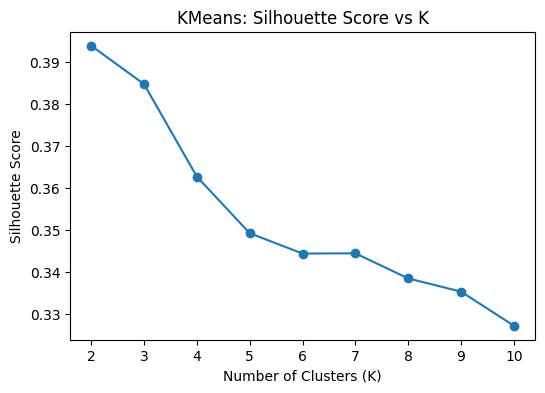

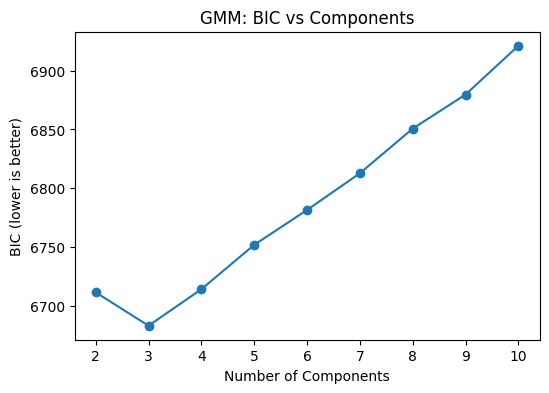

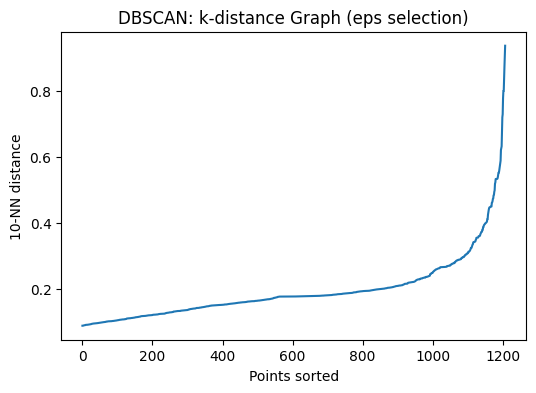

In [61]:
# =========================
# KMeans: Silhouette Plot
# =========================
def plot_k_selection(X, k_range=range(2, 11)):

    scores = []

    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42)
        labels = model.fit_predict(X)
        score = silhouette_score(X, labels)
        scores.append(score)

    plt.figure(figsize=(6,4))
    plt.plot(list(k_range), scores, marker='o')
    plt.title("KMeans: Silhouette Score vs K")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Silhouette Score")
    plt.show()


# =========================
# GMM: BIC Plot
# =========================
def plot_gmm_bic(X, k_range=range(2, 11)):

    bics = []

    for k in k_range:
        model = GaussianMixture(n_components=k, random_state=42)
        model.fit(X)
        bics.append(model.bic(X))

    plt.figure(figsize=(6,4))
    plt.plot(list(k_range), bics, marker='o')
    plt.title("GMM: BIC vs Components")
    plt.xlabel("Number of Components")
    plt.ylabel("BIC (lower is better)")
    plt.show()


# =========================
# DBSCAN: k-distance plot
# =========================
def plot_dbscan_eps(X, k=10):

    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nbrs.kneighbors(X)

    k_dist = np.sort(distances[:, -1])

    plt.figure(figsize=(6,4))
    plt.plot(k_dist)
    plt.title("DBSCAN: k-distance Graph (eps selection)")
    plt.xlabel("Points sorted")
    plt.ylabel(f"{k}-NN distance")
    plt.show()


# =========================
# RUN FOR DEMO VIEW
# =========================

plot_k_selection(X_demo_scaled)       # KMeans justification
plot_gmm_bic(X_demo_scaled)           # GMM justification
plot_dbscan_eps(X_demo_scaled)        # DBSCAN justification

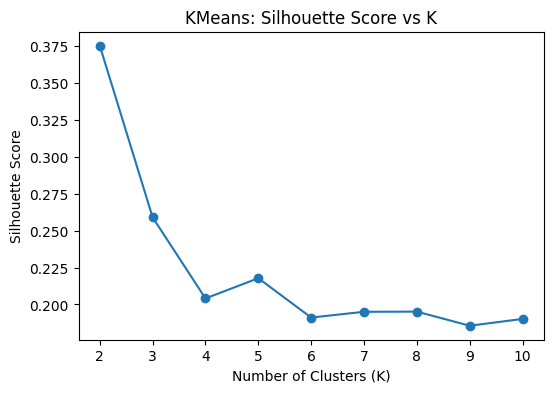

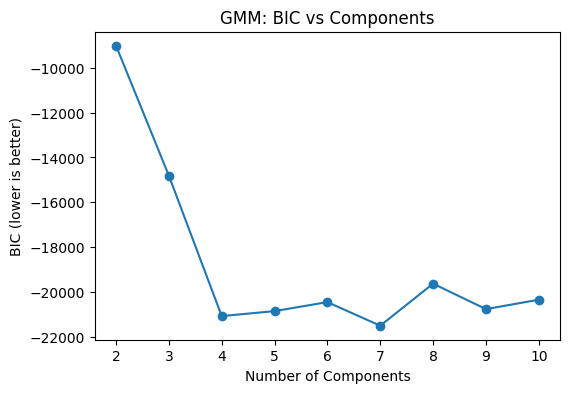

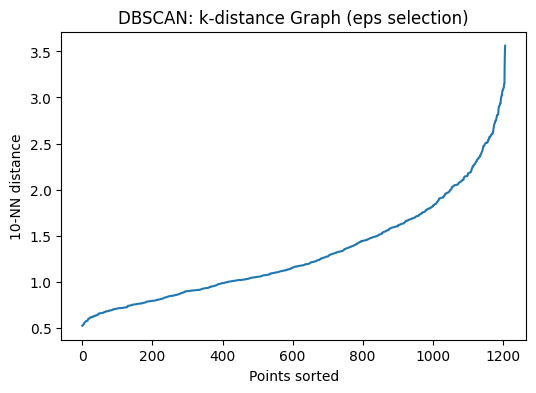

In [62]:
# =========================
# KMeans: Silhouette Plot
# =========================
def plot_k_selection(X, k_range=range(2, 11)):

    scores = []

    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42)
        labels = model.fit_predict(X)
        score = silhouette_score(X, labels)
        scores.append(score)

    plt.figure(figsize=(6,4))
    plt.plot(list(k_range), scores, marker='o')
    plt.title("KMeans: Silhouette Score vs K")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Silhouette Score")
    plt.show()


# =========================
# GMM: BIC Plot
# =========================
def plot_gmm_bic(X, k_range=range(2, 11)):

    bics = []

    for k in k_range:
        model = GaussianMixture(n_components=k, random_state=42)
        model.fit(X)
        bics.append(model.bic(X))

    plt.figure(figsize=(6,4))
    plt.plot(list(k_range), bics, marker='o')
    plt.title("GMM: BIC vs Components")
    plt.xlabel("Number of Components")
    plt.ylabel("BIC (lower is better)")
    plt.show()


# =========================
# DBSCAN: k-distance plot
# =========================
def plot_dbscan_eps(X, k=10):

    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nbrs.kneighbors(X)

    k_dist = np.sort(distances[:, -1])

    plt.figure(figsize=(6,4))
    plt.plot(k_dist)
    plt.title("DBSCAN: k-distance Graph (eps selection)")
    plt.xlabel("Points sorted")
    plt.ylabel(f"{k}-NN distance")
    plt.show()


# =========================
# RUN FOR DEMO VIEW
# =========================

plot_k_selection(X_behav_scaled)       # KMeans justification
plot_gmm_bic(X_behav_scaled)           # GMM justification
plot_dbscan_eps(X_behav_scaled)        # DBSCAN justification

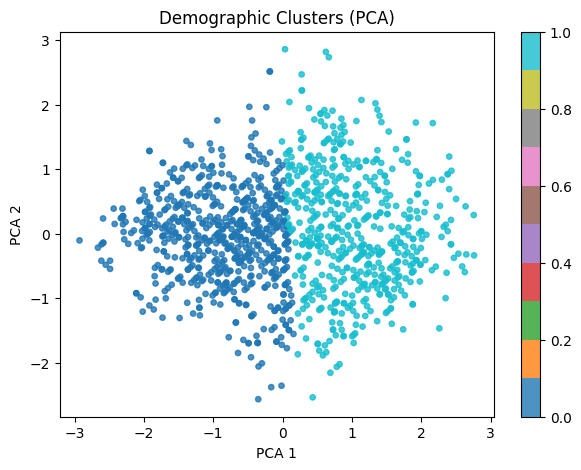

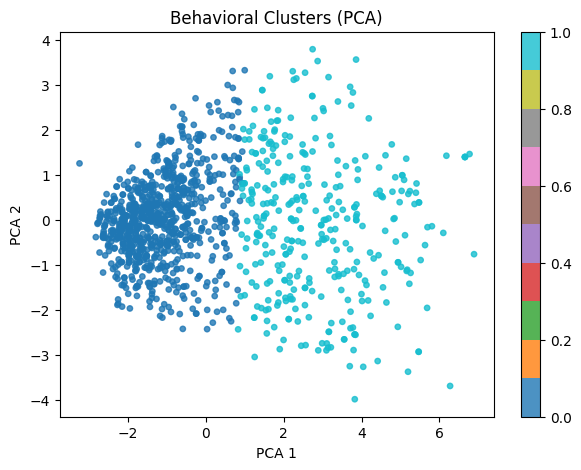


Cluster Summary:

                 Income          Age  Monetary  Frequency  \
Final_Cluster                                               
1_1            0.689885  2025.564062  1.877957   1.469434   
0_1            0.510779  2025.273469  1.756112   1.188283   
1_0            0.514709  2025.643137  0.367548   0.571512   
0_0            0.306805  2025.351225  0.323895   0.450071   

               Campaign_Engagement_Rate  Product_Diversity  Customer_Count  
Final_Cluster                                                               
1_1                                 0.0           5.632107             299  
0_1                                 0.0           5.632653              49  
1_0                                 0.0           4.925490             255  
0_0                                 0.0           5.249587             605  

Demographic View Evaluation:
Silhouette Score: 0.39702698777618667
Davies-Bouldin: 0.9889741038834656
Calinski-Harabasz: 995.1258548509411

Behavioral 

In [63]:
# =========================
# AUTO K SELECTION (KMeans)
# =========================
def best_kmeans_k(X, k_range=range(2, 11)):
    best_k, best_score = 2, -1
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X)
        score = silhouette_score(X, labels)
        if score > best_score:
            best_k, best_score = k, score
    return best_k


# =========================
# AUTO GMM (BIC)
# =========================
def best_gmm_k(X, k_range=range(2, 11)):
    best_k, best_bic = 2, np.inf
    for k in k_range:
        model = GaussianMixture(n_components=k, random_state=42)
        model.fit(X)
        bic = model.bic(X)
        if bic < best_bic:
            best_k, best_bic = k, bic
    return best_k


# =========================
# AUTO DBSCAN EPS
# =========================
def auto_eps(X, k=10):
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nbrs.kneighbors(X)
    k_dist = np.sort(distances[:, -1])
    return np.percentile(k_dist, 95)


# =========================
# CLUSTERING PIPELINE
# =========================
def run_auto_clustering(X):

    results = {}

    # unified K
    k = best_kmeans_k(X)

    # KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    results['kmeans'] = km.fit_predict(X)

    # GMM
    gmm = GaussianMixture(n_components=k, random_state=42)
    results['gmm'] = gmm.fit(X).predict(X)

    # Spectral
    spectral = SpectralClustering(
        n_clusters=k,
        random_state=42,
        assign_labels='kmeans'
    )
    results['spectral'] = spectral.fit_predict(X)

    # DBSCAN
    eps = auto_eps(X)
    db = DBSCAN(eps=eps, min_samples=10)
    results['dbscan'] = db.fit_predict(X)

    return results


# =========================
# SIMPLE ENSEMBLE (SAFE)
# =========================
def ensemble(labels_dict):
    # Avoid label mismatch problem
    return labels_dict['kmeans']


# =========================
# PCA VISUALIZATION
# =========================
def plot_clusters(X, labels, title):

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(7,5))
    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        cmap='tab10',
        s=15,
        alpha=0.8
    )

    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.colorbar()
    plt.show()


# =========================
# EVALUATION
# =========================
def evaluate(X, labels, name):

    mask = labels != -1
    X_ = X[mask]
    y_ = labels[mask]

    print(f"\n{name} Evaluation:")

    if len(np.unique(y_)) < 2:
        print("Not enough clusters for evaluation")
        return

    print("Silhouette Score:", silhouette_score(X_, y_))
    print("Davies-Bouldin:", davies_bouldin_score(X_, y_))
    print("Calinski-Harabasz:", calinski_harabasz_score(X_, y_))


# =========================
# MAIN PIPELINE
# =========================

demo_clusters = run_auto_clustering(X_demo_scaled)
behav_clusters = run_auto_clustering(X_behav_scaled)

# Ensemble (safe)
df['Cluster_Demo'] = ensemble(demo_clusters)
df['Cluster_Behav'] = ensemble(behav_clusters)

# Final Cluster (interpretable)
df['Final_Cluster'] = (
    df['Cluster_Demo'].astype(str) + "_" +
    df['Cluster_Behav'].astype(str)
)

# =========================
# VISUALIZATION
# =========================
plot_clusters(X_demo_scaled, df['Cluster_Demo'], "Demographic Clusters (PCA)")
plot_clusters(X_behav_scaled, df['Cluster_Behav'], "Behavioral Clusters (PCA)")

# =========================
# SUMMARY
# =========================
summary = df.groupby('Final_Cluster').agg({
    'Income': 'mean',
    'Age': 'mean',
    'Monetary': 'mean',
    'Frequency': 'mean',
    'Campaign_Engagement_Rate': 'mean',
    'Product_Diversity': 'mean',
    'Final_Cluster': 'count'
}).rename(columns={'Final_Cluster': 'Customer_Count'}) \
 .sort_values('Monetary', ascending=False)

print("\nCluster Summary:\n")
print(summary.head(10))


# =========================
# EVALUATION
# =========================
demo_final = df['Cluster_Demo'].values
behav_final = df['Cluster_Behav'].values

evaluate(X_demo_scaled, demo_final, "Demographic View")
evaluate(X_behav_scaled, behav_final, "Behavioral View")


# =========================
# MARKETING STRATEGY
# =========================
def assign_strategy(row):

    if row['Monetary'] > df['Monetary'].mean() and row['Frequency'] > df['Frequency'].mean():
        return "Loyal High-Value → Loyalty Program"

    elif row['Campaign_Engagement_Rate'] > 0.5:
        return "Campaign Responsive → Target Promotions"

    elif row['Monetary'] < df['Monetary'].mean():
        return "Low Value → Discount Strategy"

    else:
        return "General Customer → Nurturing Campaign"


df['Marketing_Strategy'] = df.apply(assign_strategy, axis=1)

print("\nSample Strategies:\n")
print(df[['Cluster_Demo','Cluster_Behav','Marketing_Strategy']].head())